# Delicious Asian and Indian Cuisines 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from imblearn.over_sampling import SMOTE


In [4]:
df = pd.read_csv("../data/cuisines.csv")
df.head()

,Unnamed: 0,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,65,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,66,indian,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,67,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,68,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,69,indian,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2448 entries, 0 to 2447
Columns: 385 entries, Unnamed: 0 to zucchini
dtypes: int64(384), str(1)
memory usage: 7.2 MB


<Axes: xlabel='cuisine'>

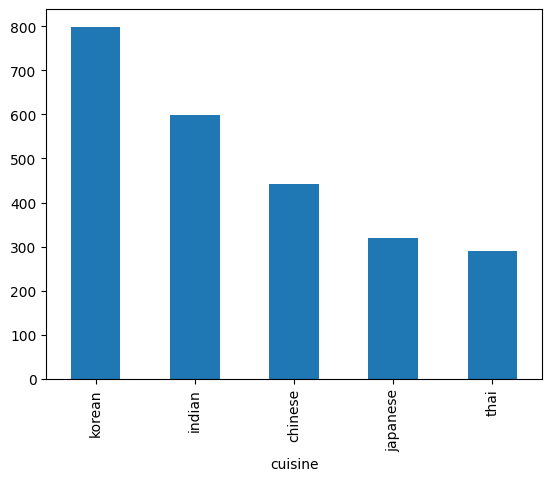

In [6]:
df.cuisine.value_counts().plot(kind="bar")

In [7]:
thai_df = df[df.cuisine == "thai"]
japanese_df = df[df.cuisine == "japanese"]
chinese_df = df[df.cuisine == "chinese"]
indian_df = df[df.cuisine == "indian"]
korean_df = df[df.cuisine == "korean"]

print(f"thai_df.shape: {thai_df.shape}")
print(f"japanese_df.shape: {japanese_df.shape}")
print(f"chinese_df.shape: {chinese_df.shape}")
print(f"indian_df.shape: {indian_df.shape}")
print(f"korean_df.shape: {korean_df.shape}")

thai_df.shape: (289, 385)
japanese_df.shape: (320, 385)
chinese_df.shape: (442, 385)
indian_df.shape: (598, 385)
korean_df.shape: (799, 385)


In [14]:
def create_ingredient_df(d):
    ingredient_df = d.T.drop(["cuisine", "Unnamed: 0"]).sum(axis=1).to_frame()
    ingredient_df = ingredient_df[(ingredient_df.T != 0).any()]
    ingredient_df = ingredient_df.sort_values(by=0, ascending=False, inplace=False)
    return ingredient_df


<Axes: >

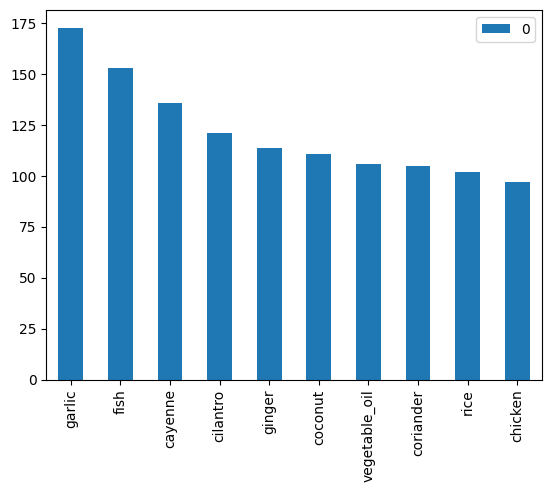

In [15]:
thai_ingredient_df = create_ingredient_df(thai_df)
thai_ingredient_df.head(10).plot(kind="bar")

<Axes: >

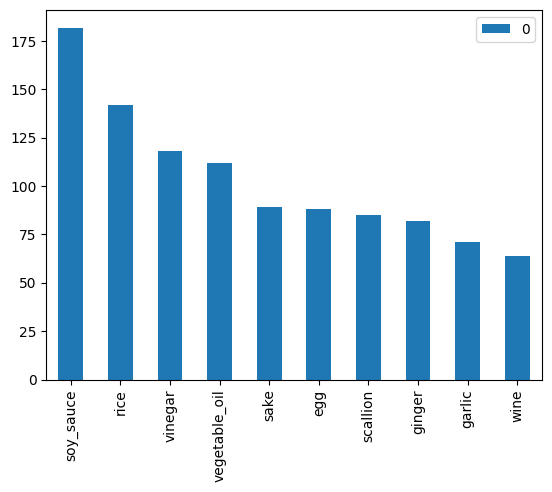

In [16]:
japanese_ingredient_df = create_ingredient_df(japanese_df)
japanese_ingredient_df.head(10).plot(kind="bar")

<Axes: >

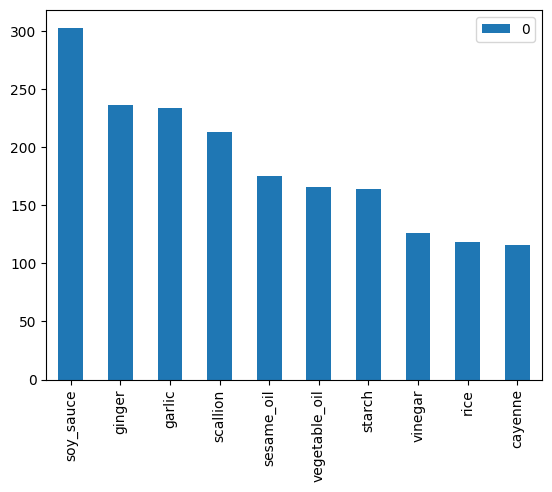

In [17]:
chinese_ingredient_df = create_ingredient_df(chinese_df)
chinese_ingredient_df.head(10).plot(kind="bar")

<Axes: >

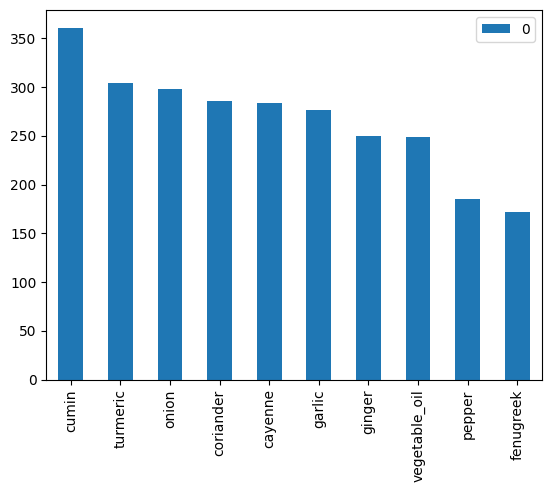

In [18]:
indian_ingredient_df = create_ingredient_df(indian_df)
indian_ingredient_df.head(10).plot(kind="bar")

<Axes: >

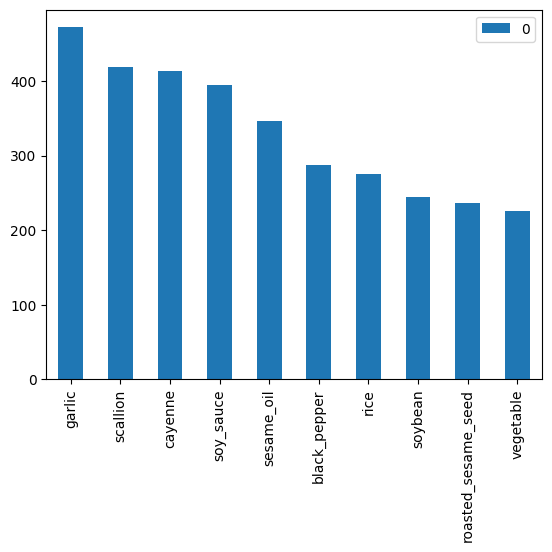

In [19]:
korean_ingredient_df = create_ingredient_df(korean_df)
korean_ingredient_df.head(10).plot(kind="bar")

In [20]:
feature_df = df.drop(["cuisine", "Unnamed: 0", 'rice', 'garlic', 'ginger'], axis=1)
labels = df.cuisine
feature_df.head()

,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,artichoke,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [22]:
#SMOTE - Synthetic Minority Oversampling Technique is technique to oversample dataset which has less records and it uses KNN and interpolation techniques.
#NearMiss - downsampling technique which uses KNN to find the nearest neighbors and then it removes the majority class samples which are far from the minority class samples.

oversample = SMOTE(random_state=42)
transformed_feature_df, transformed_labels = oversample.fit_resample(feature_df, labels)

print(f"new label count {transformed_labels.value_counts()}")
print(f"old label count {df.cuisine.value_counts()}")

new label count cuisine
indian      799
thai        799
chinese     799
japanese    799
korean      799
Name: count, dtype: int64
old label count cuisine
korean      799
indian      598
chinese     442
japanese    320
thai        289
Name: count, dtype: int64


In [23]:
transformed_df = pd.concat([transformed_labels, transformed_feature_df], axis=1)

In [24]:
transformed_df.head()
transformed_df.info()
transformed_df.to_csv("../data/cleaned_cuisines.csv")

<class 'pandas.DataFrame'>
RangeIndex: 3995 entries, 0 to 3994
Columns: 381 entries, cuisine to zucchini
dtypes: int64(380), str(1)
memory usage: 11.6 MB
